In [2]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.neighbors import BallTree


In [3]:
#load data
op_df = pd.read_csv('data/LA_County_Homeless_Encampment_Request_Forms.csv')
myla_df = pd.read_csv('data/MyLA311_Service_Request_Data_2025_20260325.csv')
myla_peh_df = myla_df[myla_df['RequestType'] == 'Homeless Encampment']
myla_peh_df.to_csv('data/MyLA311_Service_Request_Homeless_Encampment.csv')

/var/folders/1_/t205nxgn5071yp16f9p4jkkr0000gn/T/ipykernel_31189/1198618525.py:3: DtypeWarning: Columns (0: MobileOS, 1: ZipCode, 2: TBMPage) have mixed types. Specify dtype option on import or set low_memory=False.
  myla_df = pd.read_csv('data/MyLA311_Service_Request_Data_2025_20260325.csv')


In [89]:
#standardize date format
op_df['DATESUBMITTED'] = op_df['DATESUBMITTED'].str[:10].str.replace('/', '-')
op_df['REQUESTCOMPLETEDDATE'] = op_df['REQUESTCOMPLETEDDATE'].str[:10].str.replace('/', '-')
myla_peh_df["CreatedDate"] = myla_peh_df["CreatedDate"].str[:10].str.replace('/', '-')
myla_peh_df["UpdatedDate"] = myla_peh_df["UpdatedDate"].str[:10].str.replace('/', '-')

In [ ]:
print(f'starting with {len(op_df)} rows')
op_df = op_df[op_df['DATESUBMITTED'].str.startswith('2025')]
print(f'op_df filtered to 2025: {len(op_df)} rows')
print(len(myla_peh_df))

789
op_df filtered to 2025: 789 rows
24100


In [ ]:
#total no of anonymous requests
print(f'total no of anonymous requests: {len(myla_df[myla_df["Anonymous"] == "Y"])}')
pd.crosstab(index = myla_df["Anonymous"], columns = myla_df["RequestType"], normalize = "columns")
#curious! homeless encampment requests are one of the few that may be anonymous
#I wonder what predicts that?

total no of anonymous requests: 53304


RequestType,Bulky Items,Dead Animal Removal,Electronic Waste,Feedback,Graffiti Removal,Homeless Encampment,Illegal Dumping Pickup,Metal/Household Appliances,Multiple Streetlight Issue,Other,Report Water Waste,Single Streetlight Issue
Anonymous,,,,,,,,,,,,
N,0.903345,0.898909,0.954513,0.366906,0.871563,0.633693,0.855455,0.953562,0.816277,0.715718,0.795518,0.854133
Y,0.096655,0.101091,0.045487,0.633094,0.128437,0.366307,0.144545,0.046438,0.183723,0.284282,0.204482,0.145867


In [34]:
print(myla_peh_df.columns)

df = myla_peh_df.dropna(subset=['StreetName', 'Anonymous']).copy()
df['Anonymous'] = (df['Anonymous'] == 'Y').astype(int)

X = pd.get_dummies(df['StreetName'], prefix='zip')
y = df['Anonymous']

model = sklearn.linear_model.LogisticRegression(max_iter=1000)
model.fit(X, y)

print(f'Accuracy: {model.score(X, y):.3f}')
print(f'Baseline (always guess majority): {1 - y.mean():.3f}')

coeffs = pd.Series(model.coef_[0], index=X.columns).sort_values()
print('\nMost anonymous zip codes:')
print(coeffs.tail(10))
print('\nLeast anonymous zip codes:')
print(coeffs.head(10))

Index(['SRNumber', 'CreatedDate', 'UpdatedDate', 'ActionTaken', 'Owner',
       'RequestType', 'Status', 'RequestSource', 'CreatedByUserOrganization',
       'MobileOS', 'Anonymous', 'AssignTo', 'ServiceDate', 'ClosedDate',
       'AddressVerified', 'ApproximateAddress', 'Address', 'HouseNumber',
       'Direction', 'StreetName', 'Suffix', 'ZipCode', 'Latitude', 'Longitude',
       'Location', 'TBMPage', 'TBMColumn', 'TBMRow', 'APC', 'CD', 'CDMember',
       'NC', 'NCName', 'PolicePrecinct'],
      dtype='str')
Accuracy: 0.720
Baseline (always guess majority): 0.689

Most anonymous zip codes:
zip_MAPLE        1.663444
zip_FELLOWS      1.774502
zip_29TH         1.808410
zip_ALTMAN       1.929379
zip_OSWALD       1.996482
zip_ALVARADO     2.191551
zip_IROLO        2.207084
zip_NURMI        2.225383
zip_LA TIJERA    2.243629
zip_CUMPSTON     2.296558
dtype: float64

Least anonymous zip codes:
zip_MYERS        -1.941092
zip_MISSION      -1.816705
zip_46TH         -1.580800
zip_GLEDHILL    

In [ ]:
RADIUS_KM = 1.0

# prep encampment protocols: select only protocols that are full protocol or immediate action
proto_df = op_df[(op_df['REQUESTTYPENOTE'] == 'Full Encampment Protocol') | (op_df['REQUESTTYPENOTE'] == 'Immediate Action')].copy()
proto_df = proto_df[proto_df['REQUESTCOMPLETEDSTATUS'] != "prev_approved_activity_not_required"]
proto_df = proto_df.dropna(subset=['Y', 'X', 'DATESUBMITTED'])
proto_df['date'] = pd.to_datetime(proto_df['DATESUBMITTED'])
proto_coords = np.radians(proto_df[['Y', 'X']].values.astype(float))

# prep myla reports: drop missing coords/dates
reports_df = myla_peh_df.dropna(subset=['Latitude', 'Longitude', 'CreatedDate']).copy()
reports_df['date'] = pd.to_datetime(reports_df['CreatedDate'])
report_coords = np.radians(reports_df[['Latitude', 'Longitude']].values.astype(float))

# BallTree for fast spatial queries (haversine returns distance in radians)
tree = BallTree(proto_coords, metric='haversine')
radius_rad = RADIUS_KM / 6371.0

MONTH_DAYS = 30

days_since_last = np.full(len(reports_df), np.nan)
protocols_last_month = np.zeros(len(reports_df), dtype=int)

for i, (coord, report_date) in enumerate(zip(report_coords, reports_df['date'])):
    idxs = tree.query_radius([coord], r=radius_rad)[0]
    if len(idxs) == 0:
        continue
    proto_dates = proto_df.iloc[idxs]['date'].values
    days_before = (np.datetime64(report_date) - proto_dates).astype('timedelta64[D]').astype(int)
    past = days_before[days_before >= 0]
    if len(past) > 0:
        days_since_last[i] = past.min()
    protocols_last_month[i] = ((days_before >= 0) & (days_before <= MONTH_DAYS)).sum()

reports_df['days_since_last_protocol'] = days_since_last
reports_df['protocols_nearby_last_month'] = protocols_last_month


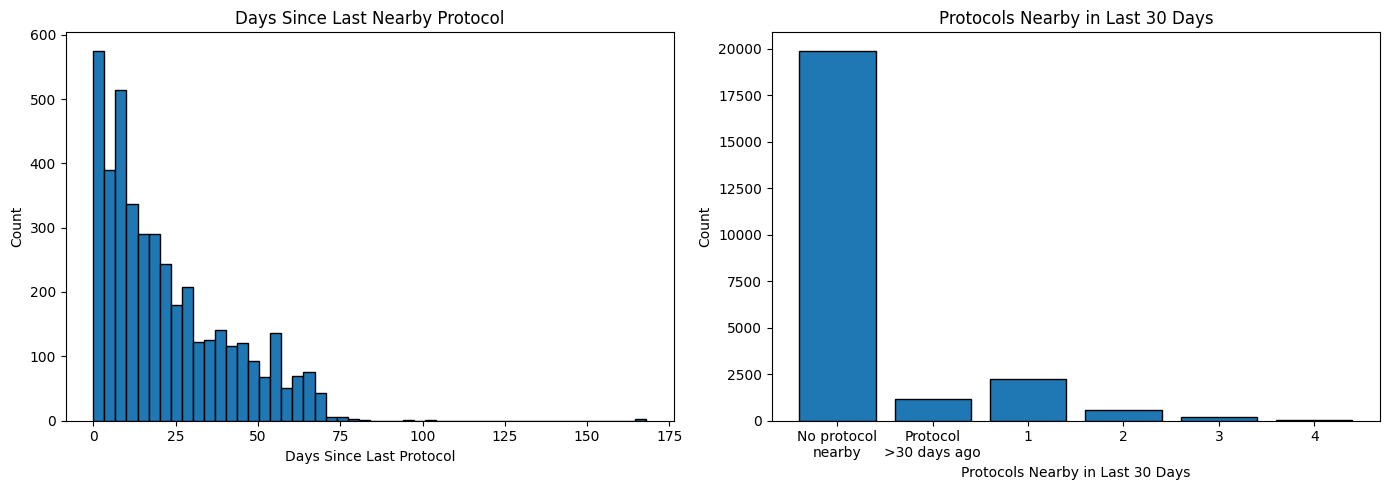

In [72]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# plot 1: distribution of days since last nearby protocol
ax1.hist(reports_df['days_since_last_protocol'].dropna(), bins=50, edgecolor='black')
ax1.set_xlabel('Days Since Last Protocol')
ax1.set_ylabel('Count')
ax1.set_title('Days Since Last Nearby Protocol')

# plot 2: protocols nearby in last 30 days
# split the 0 bucket: no protocol nearby at all vs protocol >30 days ago
no_nearby = reports_df['days_since_last_protocol'].isna().sum()
over_30 = ((reports_df['days_since_last_protocol'].notna()) & (reports_df['protocols_nearby_last_month'] == 0)).sum()
counts = reports_df.loc[reports_df['protocols_nearby_last_month'] > 0, 'protocols_nearby_last_month'].value_counts().sort_index()
labels = ['No protocol\nnearby', 'Protocol\n>30 days ago'] + [str(v) for v in counts.index]
values = [no_nearby, over_30] + counts.tolist()
ax2.bar(labels, values, edgecolor='black')
ax2.set_xlabel('Protocols Nearby in Last 30 Days')
ax2.set_ylabel('Count')
ax2.set_title('Protocols Nearby in Last 30 Days')

plt.tight_layout()
plt.show()

In [73]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(reports_df, test_size=0.5, random_state=42)
print(f'Train: {len(train_df)}, Test: {len(test_df)}')

Train: 12050, Test: 12050


In [77]:
reports_df.head()

,SRNumber,CreatedDate,UpdatedDate,ActionTaken,Owner,RequestType,Status,RequestSource,CreatedByUserOrganization,MobileOS,...,TBMRow,APC,CD,CDMember,NC,NCName,PolicePrecinct,date,days_since_last_protocol,protocols_nearby_last_month
1,1-5100400341,01-01-2025,01-01-2025,SR Created,LASAN,Homeless Encampment,Closed,Mobile App,Self Service,iOS,...,7.0,South Los Angeles APC,9.0,Curren D. Price Jr.,78.0,South Central,NEWTON,2025-01-01,NaN,0
8,1-5100399711,01-01-2025,01-01-2025,SR Created,LASAN,Homeless Encampment,Closed,Mobile App,Self Service,iOS,...,4.0,Central APC,5.0,Katy Yaroslavsky,60.0,P.I.C.O.,WILSHIRE,2025-01-01,NaN,0
25,1-5100413201,01-01-2025,01-01-2025,SR Created,LASAN,Homeless Encampment,Closed,Mobile App,Self Service,iOS,...,7.0,South Valley APC,6.0,Imelda Padilla,20.0,Van Nuys,VAN NUYS,2025-01-01,NaN,0
34,1-5100413611,01-01-2025,01-01-2025,SR Created,LASAN,Homeless Encampment,Closed,Self Service,Self Service,NaN,...,2.0,Central APC,13.0,Hugo Soto-Martinez,97.0,Westlake North,RAMPART,2025-01-01,NaN,0
45,1-5100430221,01-01-2025,01-01-2025,SR Created,LASAN,Homeless Encampment,Closed,Mobile App,Self Service,iOS,...,4.0,Central APC,13.0,Hugo Soto-Martinez,29.0,Hollywood Hills West,HOLLYWOOD,2025-01-01,NaN,0


In [78]:
op_df.columns

Index(['X', 'Y', 'OBJECTID', 'REQUESTAPPROVALSTATUS', 'REQUESTCOMPLETEDNOTE',
       'REQUESTTYPENOTE', 'DATESUBMITTED', 'ADDRESS_OR_LOCATION_OF_CALL',
       'ADDRESS', 'SD', 'SPA', 'CITY', 'LESSTHAN5PEH', 'POSSIBLEDWELLERS',
       'COLLABORATORDATEAVAILABILITY', 'REQUESTCOMPLETEDSTATUS',
       'AMOUNTDEBRISREMOVEDINT', 'REQUESTCOMPLETEDDATE', 'GLOBALID'],
      dtype='str')

In [97]:
myla_peh_df['ActionTaken'].unique()

<ArrowStringArray>
['SR Created', 'Transferred', 'Long Distance Call Support']
Length: 3, dtype: str

In [98]:
MATCH_THRESHOLD_KM = 0.2  # 200 meters

op_match = op_df.dropna(subset=['Y', 'X']).copy()
myla_match = myla_peh_df.dropna(subset=['Latitude', 'Longitude']).copy()

op_coords = np.radians(op_match[['Y', 'X']].values.astype(float))
myla_coords = np.radians(myla_match[['Latitude', 'Longitude']].values.astype(float))

tree = BallTree(op_coords, metric='haversine')
dist_rad, idx = tree.query(myla_coords, k=1)
dist_km = dist_rad.flatten() * 6371.0
nearest_idx = idx.flatten()

matched = dist_km <= MATCH_THRESHOLD_KM

nearest_op = op_match.iloc[nearest_idx]

merged = pd.DataFrame({
    'myla_lat': myla_match['Latitude'].values,
    'myla_lon': myla_match['Longitude'].values,
    'myla_address_verified': myla_match['AddressVerified'].values,
    'myla_action_taken': myla_match['ActionTaken'].values,
    'op_lat': nearest_op['Y'].values,
    'op_lon': nearest_op['X'].values,
    'op_address': nearest_op['ADDRESS'].values,
    'op_possible_dwellers': nearest_op['POSSIBLEDWELLERS'].values,
    'distance_km': dist_km,
    'coords_match': matched,
})

print(f'Total rows: {len(merged)}')
print(f'Matches (within {MATCH_THRESHOLD_KM*1000:.0f}m): {matched.sum()}')
print(f'No match: {(~matched).sum()}')
merged

Total rows: 24100
Matches (within 200m): 582
No match: 23518


,myla_lat,myla_lon,myla_address_verified,myla_action_taken,op_lat,op_lon,op_address,op_possible_dwellers,distance_km,coords_match
0,34.027014,-118.267546,Y,SR Created,33.989162,-118.256164,"1118 E Slauson Ave, cross street Central Ave",4,4.337783,False
1,34.052308,-118.367834,Y,SR Created,33.996142,-118.358093,5005 La Brea ave xst Overhill dr.,2,6.309578,False
2,34.182792,-118.470904,Y,SR Created,34.199137,-118.495551,"Bull Creek, left (east) bank, downstream (sout...",1,2.905592,False
3,34.067113,-118.271370,Y,SR Created,34.083172,-118.221525,Encampment is on the invert of Arroyo Seco Cha...,2,4.925941,False
4,34.104921,-118.337287,Y,SR Created,34.143067,-118.361829,"LA River, right (south) bank, upstream (west) ...",3,4.805759,False
...,...,...,...,...,...,...,...,...,...,...
24095,34.042244,-118.249202,Y,SR Created,34.083172,-118.221525,Encampment is on the invert of Arroyo Seco Cha...,2,5.216413,False
24096,34.042119,-118.250014,Y,SR Created,34.083172,-118.221525,Encampment is on the invert of Arroyo Seco Cha...,2,5.265463,False
24097,34.042244,-118.249202,Y,SR Created,34.083172,-118.221525,Encampment is on the invert of Arroyo Seco Cha...,2,5.216413,False
24098,34.040964,-118.247374,Y,SR Created,34.036011,-118.192001,3509 1st St xst Indiana St,1,5.131900,False


In [ ]:
DEDUP_THRESHOLD_KM = 0.1  # 100 meters — same encampment

myla_geo = myla_peh_df.dropna(subset=['Latitude', 'Longitude']).copy()
myla_rad = np.radians(myla_geo[['Latitude', 'Longitude']].values.astype(float))

myla_tree = BallTree(myla_rad, metric='haversine')
dedup_rad = DEDUP_THRESHOLD_KM / 6371.0

# for each report, count how many other reports are within the threshold
counts = myla_tree.query_radius(myla_rad, r=dedup_rad, count_only=True)
myla_geo['nearby_reports'] = counts  # includes self

dupes = myla_geo[myla_geo['nearby_reports'] > 1].sort_values('nearby_reports', ascending=False)

print(f'Total myla reports with coords: {len(myla_geo)}')
print(f'Reports with at least 1 nearby duplicate: {len(dupes)} ({len(dupes)/len(myla_geo)*100:.1f}%)')
print(f'Reports with no nearby duplicate: {len(myla_geo) - len(dupes)}')
print(f'\nDistribution of nearby_reports (including self):')
print(myla_geo['nearby_reports'].describe())

dupes[['Latitude', 'Longitude', 'Address', 'CreatedDate', 'ActionTaken', 'nearby_reports']]

Total myla reports with coords: 24100
Reports with at least 1 nearby duplicate: 22491 (93.3%)
Reports with no nearby duplicate: 1609

Distribution of nearby_reports (including self):
count    24100.000000
mean        51.708797
std        113.428012
min          1.000000
25%          5.000000
50%         14.000000
75%         36.000000
max        527.000000
Name: nearby_reports, dtype: float64


,Latitude,Longitude,Address,CreatedDate,ActionTaken,nearby_reports
14328,34.058176,-118.275539,"642 S ALVARADO ST, 90057",01-03-2025,SR Created,527
128650,34.058110,-118.275670,"642 S ALVARADO ST, 90057",01-29-2025,SR Created,527
137320,34.058176,-118.275539,"642 S ALVARADO ST, 90057",01-31-2025,SR Created,527
12927,34.058176,-118.275539,"642 S ALVARADO ST, 90057",01-03-2025,SR Created,527
166655,34.058176,-118.275539,"642 S ALVARADO ST, 90057",02-07-2025,SR Created,527
...,...,...,...,...,...,...
219220,33.971139,-118.374337,"5344 W THORNBURN ST, 90045",02-21-2025,SR Created,2
255460,33.947456,-118.281182,"419 W 98TH ST, 90003",03-01-2025,SR Created,2
21734,33.919215,-118.428960,"12700 S VISTA DEL MAR, 90245",01-05-2025,SR Created,2
112599,34.026859,-118.413064,"3348 S OVERLAND AVE, 90034",01-27-2025,SR Created,2


In [ ]:
# 1. Geographic coverage: which CITY values in op_df have no myla equivalent?
print("=== op_df CITY distribution ===")
print(op_df['CITY'].value_counts().head(20))
print(f"\nUnique cities in op_df: {op_df['CITY'].nunique()}")

# myla is all City of LA -- check if op_df has entries outside city limits
non_la = op_df[~op_df['CITY'].str.contains('Los Angeles', case=False, na=False)]
print(f"\nop_df rows OUTSIDE City of Los Angeles: {len(non_la)} / {len(op_df)} ({len(non_la)/len(op_df)*100:.1f}%)")
print(non_la['CITY'].value_counts())

In [ ]:
# 2. Time distribution comparison
op_dates = pd.to_datetime(op_df['DATESUBMITTED'])
myla_dates = pd.to_datetime(myla_peh_df['CreatedDate'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.hist(myla_dates.dropna(), bins=52, edgecolor='black')
ax1.set_ylabel('Count')
ax1.set_title(f'MyLA311 Homeless Encampment Reports by Week (n={len(myla_dates.dropna())})')

ax2.hist(op_dates.dropna(), bins=52, edgecolor='black', color='orange')
ax2.set_ylabel('Count')
ax2.set_title(f'LA County Encampment Protocol Requests by Week (n={len(op_dates.dropna())})')
ax2.set_xlabel('Date')

plt.tight_layout()
plt.show()

In [106]:
# 3. After deduplication by location AND date, how many unique encampment events?
from sklearn.cluster import DBSCAN

myla_geo = myla_peh_df.dropna(subset=['Latitude', 'Longitude', 'CreatedDate']).copy()
myla_geo['date'] = pd.to_datetime(myla_geo['CreatedDate'])
myla_rad = np.radians(myla_geo[['Latitude', 'Longitude']].values.astype(float))

# step 1: cluster by location (100m)
loc_clustering = DBSCAN(eps=0.1/6371.0, min_samples=1, metric='haversine').fit(myla_rad)
myla_geo['loc_cluster'] = loc_clustering.labels_
n_locations = myla_geo['loc_cluster'].nunique()

# step 2: within each location cluster, sub-cluster by date (7-day window)
myla_geo['event_id'] = -1
event_counter = 0
for loc_id, group in myla_geo.groupby('loc_cluster'):
    days = (group['date'] - group['date'].min()).dt.days.values.reshape(-1, 1)
    date_clustering = DBSCAN(eps=7, min_samples=1, metric='euclidean').fit(days)
    for sub_id in np.unique(date_clustering.labels_):
        myla_geo.loc[group.index[date_clustering.labels_ == sub_id], 'event_id'] = event_counter
        event_counter += 1

n_events = myla_geo['event_id'].nunique()
event_sizes = myla_geo['event_id'].value_counts()

print(f"Total reports (with coords+date): {len(myla_geo)}")
print(f"Unique locations (100m clusters): {n_locations}")
print(f"Unique events (location + 7-day window): {n_events}")
print(f"Average reports per event: {len(myla_geo)/n_events:.1f}")
print(f"\nReports that are duplicates of another report: {len(myla_geo) - n_events}")
print(f"Duplicate rate: {(len(myla_geo) - n_events)/len(myla_geo)*100:.1f}%")
print(f"\nEvent size distribution:")
print(event_sizes.describe())
print(f"\nTop 10 most-reported events:")
top10 = event_sizes.head(10)
for eid, count in top10.items():
    sample = myla_geo[myla_geo['event_id'] == eid].iloc[0]
    date_range = myla_geo[myla_geo['event_id'] == eid]['date']
    print(f"  {count} reports @ {sample['Address']} ({date_range.min().date()} to {date_range.max().date()})")

Total reports (with coords+date): 24100
Unique locations (100m clusters): 3616
Unique events (location + 7-day window): 6542
Average reports per event: 3.7

Reports that are duplicates of another report: 17558
Duplicate rate: 72.9%

Event size distribution:
count    6542.000000
mean        3.683889
std        17.382019
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max      1031.000000
Name: count, dtype: float64

Top 10 most-reported events:
  1031 reports @ WILSHIRE BLVD AT ALVARADO ST, 90057 (2025-01-01 to 2025-03-27)
  338 reports @ 8TH ST AT ALVARADO ST, 90057 (2025-01-02 to 2025-03-27)
  317 reports @ 7TH ST AT ALVARADO ST, 90057 (2025-01-22 to 2025-02-10)
  213 reports @ 13300 W RIVERSIDE DR, 91423 (2025-01-27 to 2025-03-28)
  207 reports @ 1320 E NEWTON ST, 90021 (2025-01-02 to 2025-03-25)
  191 reports @ DURANGO AVE AT EXPOSITION DR, 90034 (2025-01-01 to 2025-03-28)
  171 reports @ NEW HAMPSHIRE AVE AT OAKWOOD AVE, 90004 (2025-01-01 to 2025

In [ ]:
# 4. Reverse match: which op_df protocols have NO nearby myla report?
op_geo = op_df.dropna(subset=['Y', 'X']).copy()
op_rad = np.radians(op_geo[['Y', 'X']].values.astype(float))
myla_rad_all = np.radians(
    myla_peh_df.dropna(subset=['Latitude', 'Longitude'])[['Latitude', 'Longitude']].values.astype(float)
)

reverse_tree = BallTree(myla_rad_all, metric='haversine')
r_dist, _ = reverse_tree.query(op_rad, k=1)
r_dist_km = r_dist.flatten() * 6371.0

op_geo['nearest_myla_km'] = r_dist_km
op_geo['has_myla_report_nearby'] = r_dist_km <= 0.2

print(f"op_df protocols WITH a nearby myla report (200m): {op_geo['has_myla_report_nearby'].sum()} / {len(op_geo)}")
print(f"op_df protocols with NO nearby myla report: {(~op_geo['has_myla_report_nearby']).sum()}")

orphan_ops = op_geo[~op_geo['has_myla_report_nearby']].sort_values('nearest_myla_km', ascending=False)
print(f"\nop_df entries with no nearby myla report -- are these outside City of LA?")
print(orphan_ops[['CITY', 'ADDRESS', 'REQUESTTYPENOTE', 'nearest_myla_km']].head(20))

In [103]:
# 5. Request type breakdown in op_df
print("=== op_df request types ===")
print(op_df['REQUESTTYPENOTE'].value_counts())
print()
print("=== op_df completion status ===")
print(op_df['REQUESTCOMPLETEDSTATUS'].value_counts())
print()
print("=== op_df approval status ===")
print(op_df['REQUESTAPPROVALSTATUS'].value_counts())

=== op_df request types ===
REQUESTTYPENOTE
Non-Displacement            317
Immediate Action            274
Full Encampment Protocol    198
Name: count, dtype: int64

=== op_df completion status ===
REQUESTCOMPLETEDSTATUS
yes                                    633
prev_approved_activity_not_required    117
no                                       7
Name: count, dtype: int64

=== op_df approval status ===
REQUESTAPPROVALSTATUS
Request Completed                                750
Approved by CEO-HI                                38
Pending Next Level Approval from Request Team      1
Name: count, dtype: int64


/var/folders/1_/t205nxgn5071yp16f9p4jkkr0000gn/T/ipykernel_63206/1869401859.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  myla_times['closed'] = pd.to_datetime(myla_times['ClosedDate'])


Reports with both created and closed dates: 24100 / 24100
Still open (no closed date): 0

Days to close:
count    24100.000000
mean         0.013112
std          1.439311
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        158.000000
Name: days_to_close, dtype: float64

Median: 0 days


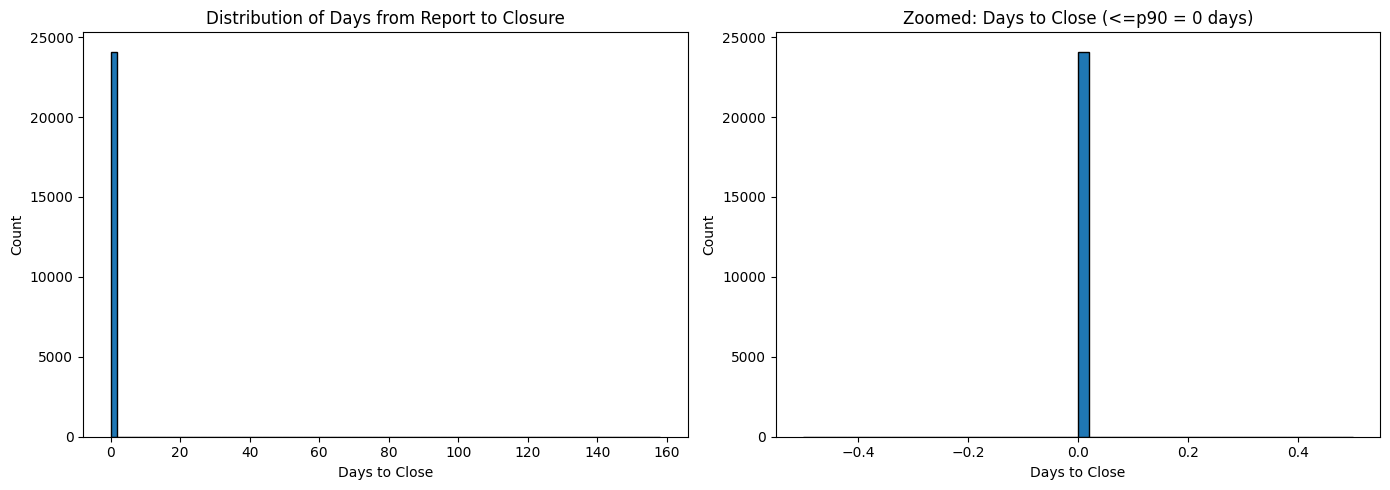

In [105]:
myla_times = myla_peh_df.dropna(subset=['CreatedDate', 'ClosedDate']).copy()
myla_times['created'] = pd.to_datetime(myla_times['CreatedDate'])
myla_times['closed'] = pd.to_datetime(myla_times['ClosedDate'])
myla_times['days_to_close'] = (myla_times['closed'] - myla_times['created']).dt.days

print(f"Reports with both created and closed dates: {len(myla_times)} / {len(myla_peh_df)}")
print(f"Still open (no closed date): {myla_peh_df['ClosedDate'].isna().sum()}")
print(f"\nDays to close:")
print(myla_times['days_to_close'].describe())
print(f"\nMedian: {myla_times['days_to_close'].median():.0f} days")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(myla_times['days_to_close'], bins=80, edgecolor='black')
ax1.set_xlabel('Days to Close')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of Days from Report to Closure')

# zoom in on the bulk (cap at 90th percentile)
p90 = myla_times['days_to_close'].quantile(0.9)
ax2.hist(myla_times[myla_times['days_to_close'] <= p90]['days_to_close'], bins=50, edgecolor='black')
ax2.set_xlabel('Days to Close')
ax2.set_ylabel('Count')
ax2.set_title(f'Zoomed: Days to Close (<=p90 = {p90:.0f} days)')

plt.tight_layout()
plt.show()

##From this I can conclude: there is no time between opening and closing date.
#is anyone looking at these then?? do they just close them immediately after doing nothing?
#concerning

In [100]:
len(myla_peh_df)

24100

In [101]:
len(op_df)

789